# SDTM Domain Classifier
### Classifying CDISC SDTM Domains using KNN and CART (Decision Tree)

**Objective:** Given a variable label from a clinical trial dataset, predict which SDTM domain it belongs to.

**Domains covered:** DM · AE · CM · EX · LB · VS · MH · PE · EG · SC

**Models compared:** K-Nearest Neighbors (KNN) vs Classification and Regression Tree (CART)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams['figure.dpi'] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Explore the Dataset

In [2]:
import os

# Load dataset - locate relative to notebook directory
notebook_dir = os.path.dirname(os.path.abspath("sdtm_classifier.ipynb"))
data_path = os.path.join(notebook_dir, "data", "sdtm_variables.csv")

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

Dataset shape: (266, 3)

Columns: ['variable_name', 'variable_label', 'domain']


,variable_name,variable_label,domain
0,STUDYID,Study Identifier,DM
1,DOMAIN,Domain Abbreviation,DM
2,USUBJID,Unique Subject Identifier,DM
3,SUBJID,Subject Identifier for the Study,DM
4,RFSTDTC,Subject Reference Start Date Time,DM
5,RFENDTC,Subject Reference End Date Time,DM
6,RFXSTDTC,Date Time of First Study Treatment,DM
7,RFXENDTC,Date Time of Last Study Treatment,DM
8,RFICDTC,Date Time of Informed Consent,DM
9,RFPENDTC,Date Time of End of Participation,DM


=== Data Types ===
variable_name     str
variable_label    str
domain            str
dtype: object

=== Missing Values ===
variable_name     0
variable_label    0
domain            0
dtype: int64

=== Domain Distribution ===
domain
VS    34
DM    32
LB    31
AE    28
CM    28
EG    28
MH    24
EX    23
PE    22
SC    16
Name: count, dtype: int64


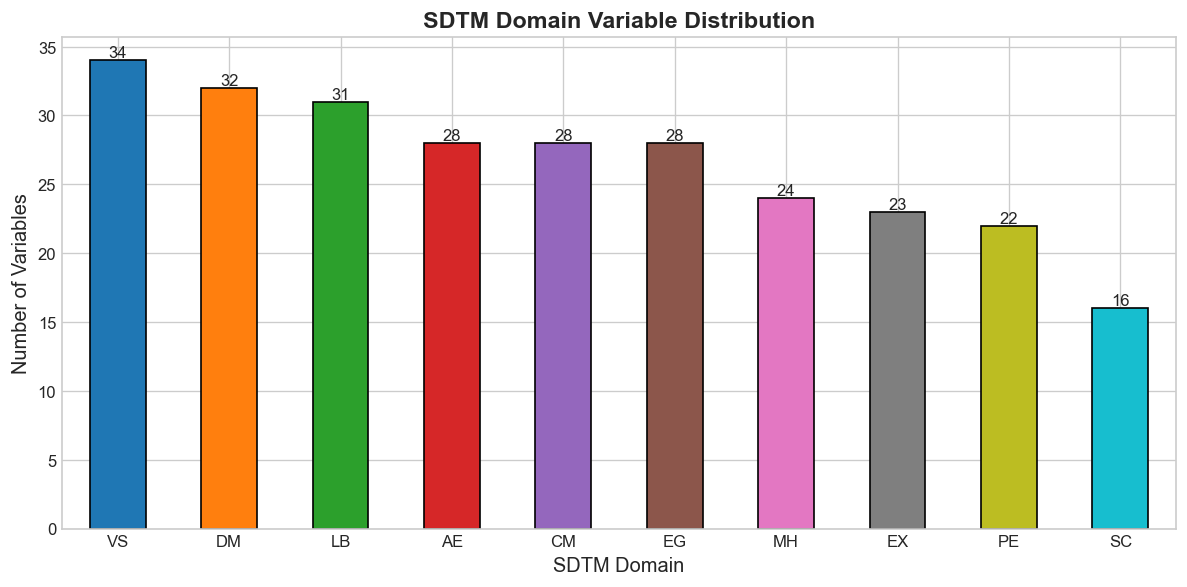

In [3]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Domain Distribution ===")
domain_counts = df['domain'].value_counts()
print(domain_counts)

# Plot domain distribution
fig, ax = plt.subplots(figsize=(10, 5))
domain_counts.plot(kind='bar', ax=ax, color=sns.color_palette('tab10', len(domain_counts)), edgecolor='black')
ax.set_title('SDTM Domain Variable Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('SDTM Domain', fontsize=12)
ax.set_ylabel('Number of Variables', fontsize=12)
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height())}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing and Label Encoding

In [4]:
# Drop rows with missing values (none expected, but defensive)
df_clean = df.dropna().copy()
print(f"Records after cleaning: {len(df_clean)}")

# Encode target labels (domain) with LabelEncoder
le = LabelEncoder()
df_clean['domain_encoded'] = le.fit_transform(df_clean['domain'])

# Display mapping
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("\n=== Domain → Encoded Label Mapping ===")
for domain, code in sorted(label_map.items()):
    print(f"  {domain:5s}  →  {code}")

Records after cleaning: 266

=== Domain → Encoded Label Mapping ===
  AE     →  0
  CM     →  1
  DM     →  2
  EG     →  3
  EX     →  4
  LB     →  5
  MH     →  6
  PE     →  7
  SC     →  8
  VS     →  9


## 4. Feature Engineering from Labels
We combine the `variable_name` and `variable_label` text, then apply **TF-IDF vectorization** to create numeric features.  
TF-IDF captures term importance across documents (labels), making it an effective feature for text-based classification.

In [5]:
# Combine variable_name + variable_label as the text corpus for each record
df_clean['text'] = df_clean['variable_name'].str.lower() + ' ' + df_clean['variable_label'].str.lower()

# TF-IDF Vectorization (unigrams + bigrams, max 200 features)
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=200,
    sublinear_tf=True,
    stop_words='english'
)

X = tfidf.fit_transform(df_clean['text']).toarray()
y = df_clean['domain_encoded'].values

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Number of classes    : {len(le.classes_)}")
print(f"Classes              : {list(le.classes_)}")

# Show top TF-IDF features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample TF-IDF features: {feature_names[:20]}")

Feature matrix shape : (266, 200)
Target vector shape  : (266,)
Number of classes    : 10
Classes              : ['AE', 'CM', 'DM', 'EG', 'EX', 'LB', 'MH', 'PE', 'SC', 'VS']

Sample TF-IDF features: ['actual' 'administration' 'administration concomitant'
 'administration exposure' 'adverse' 'adverse event' 'aehlgt'
 'aehlgt high' 'aehlt' 'aehlt high' 'aeout' 'aeout outcome' 'aerel'
 'aerel causality' 'age' 'arm' 'arm code' 'baseline' 'baseline flag'
 'body']


## 5. Split Data into Training and Testing Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y      # keep class proportions balanced in both splits
)

print(f"Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set      : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")

# Class distribution in each split
train_dist = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts().sort_index()
test_dist  = pd.Series(y_test).map(dict(enumerate(le.classes_))).value_counts().sort_index()

split_df = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
print("\n=== Class Distribution per Split ===")
print(split_df)

Training set  : 199 samples (75%)
Test set      : 67 samples  (25%)

=== Class Distribution per Split ===
    Train  Test
AE     21     7
CM     21     7
DM     24     8
EG     21     7
EX     17     6
LB     23     8
MH     18     6
PE     17     5
SC     12     4
VS     25     9


## 6. Train KNN Model
We use cross-validation over a range of **k** values to select the optimal number of neighbors.

Best k = 12  (CV accuracy = 0.9096)


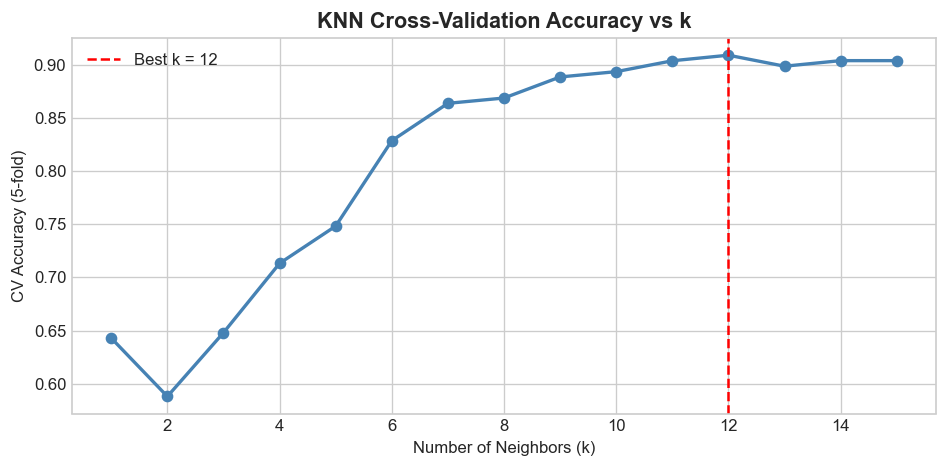


KNN model trained with k=12, metric='cosine'


In [7]:
# Tune k via cross-validation on training data
k_range = range(1, 16)
cv_scores = []
for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"Best k = {best_k}  (CV accuracy = {max(cv_scores):.4f})")

# Plot CV accuracy vs k
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), cv_scores, marker='o', linewidth=2, color='steelblue')
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
ax.set_title('KNN Cross-Validation Accuracy vs k', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Neighbors (k)')
ax.set_ylabel('CV Accuracy (5-fold)')
ax.legend()
plt.tight_layout()
plt.show()

# Train final KNN with best k
knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine')
knn.fit(X_train, y_train)
print(f"\nKNN model trained with k={best_k}, metric='cosine'")

## 7. Train CART Model
CART (Classification and Regression Trees) uses the **Gini impurity** criterion.  
We tune `max_depth` and `min_samples_split` via cross-validation.

In [8]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 4, 6]
}

cart_gs = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
cart_gs.fit(X_train, y_train)

best_depth = cart_gs.best_params_['max_depth']
best_min_split = cart_gs.best_params_['min_samples_split']
print(f"Best params : max_depth={best_depth}, min_samples_split={best_min_split}")
print(f"Best CV accuracy : {cart_gs.best_score_:.4f}")

# Final CART model
cart = cart_gs.best_estimator_
print(f"\nCART model trained successfully.")

Best params : max_depth=10, min_samples_split=2
Best CV accuracy : 0.9847

CART model trained successfully.


## 8. Evaluate KNN Model

         KNN MODEL EVALUATION
  Accuracy  : 0.8358
  Precision : 0.8487
  Recall    : 0.8358
  F1-Score  : 0.8361

Classification Report:

              precision    recall  f1-score   support

          AE       1.00      0.86      0.92         7
          CM       0.83      0.71      0.77         7
          DM       0.62      0.62      0.62         8
          EG       0.62      0.71      0.67         7
          EX       0.86      1.00      0.92         6
          LB       1.00      0.75      0.86         8
          MH       0.86      1.00      0.92         6
          PE       0.83      1.00      0.91         5
          SC       0.80      1.00      0.89         4
          VS       1.00      0.89      0.94         9

    accuracy                           0.84        67
   macro avg       0.84      0.85      0.84        67
weighted avg       0.85      0.84      0.84        67



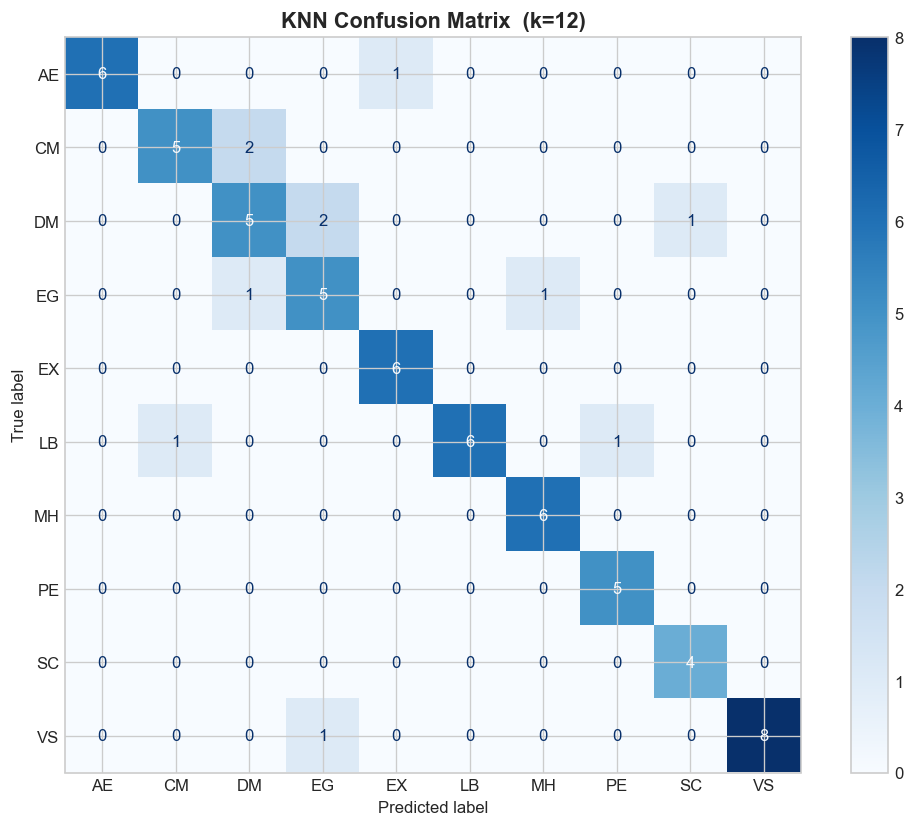

In [9]:
y_pred_knn = knn.predict(X_test)

knn_accuracy  = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_recall    = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_f1        = f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print("=" * 50)
print("         KNN MODEL EVALUATION")
print("=" * 50)
print(f"  Accuracy  : {knn_accuracy:.4f}")
print(f"  Precision : {knn_precision:.4f}")
print(f"  Recall    : {knn_recall:.4f}")
print(f"  F1-Score  : {knn_f1:.4f}")
print("=" * 50)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_, zero_division=0))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'KNN Confusion Matrix  (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluate CART Model

        CART MODEL EVALUATION
  Accuracy  : 0.9851
  Precision : 0.9867
  Recall    : 0.9851
  F1-Score  : 0.9849

Classification Report:

              precision    recall  f1-score   support

          AE       1.00      0.86      0.92         7
          CM       1.00      1.00      1.00         7
          DM       0.89      1.00      0.94         8
          EG       1.00      1.00      1.00         7
          EX       1.00      1.00      1.00         6
          LB       1.00      1.00      1.00         8
          MH       1.00      1.00      1.00         6
          PE       1.00      1.00      1.00         5
          SC       1.00      1.00      1.00         4
          VS       1.00      1.00      1.00         9

    accuracy                           0.99        67
   macro avg       0.99      0.99      0.99        67
weighted avg       0.99      0.99      0.98        67



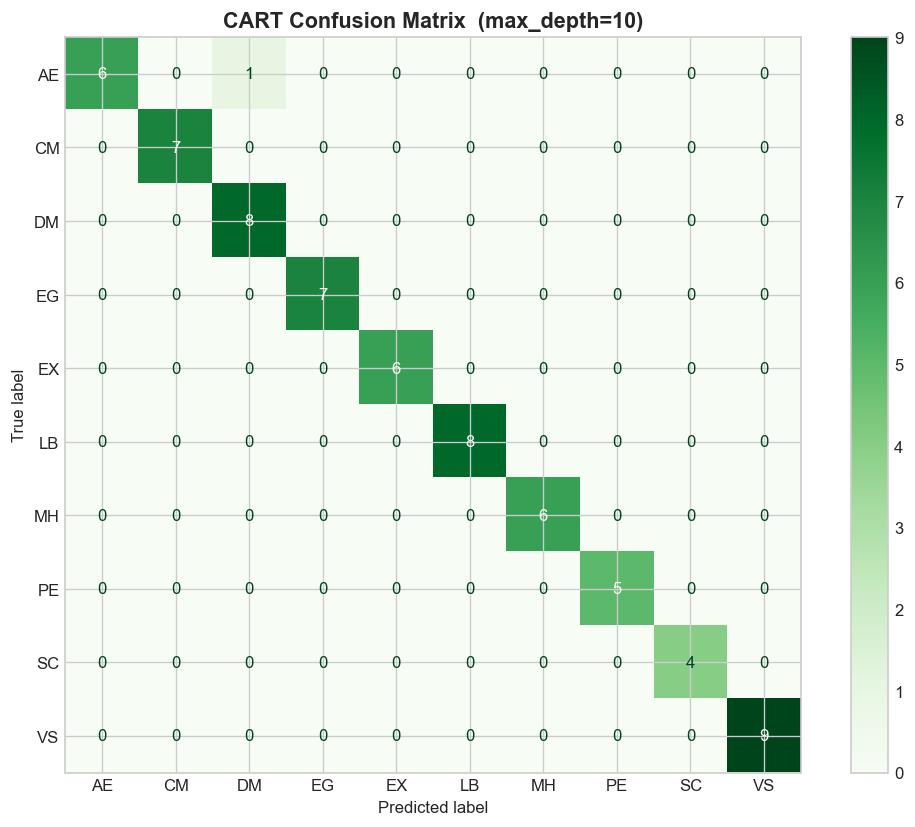

In [10]:
y_pred_cart = cart.predict(X_test)

cart_accuracy  = accuracy_score(y_test, y_pred_cart)
cart_precision = precision_score(y_test, y_pred_cart, average='weighted', zero_division=0)
cart_recall    = recall_score(y_test, y_pred_cart, average='weighted', zero_division=0)
cart_f1        = f1_score(y_test, y_pred_cart, average='weighted', zero_division=0)

print("=" * 50)
print("        CART MODEL EVALUATION")
print("=" * 50)
print(f"  Accuracy  : {cart_accuracy:.4f}")
print(f"  Precision : {cart_precision:.4f}")
print(f"  Recall    : {cart_recall:.4f}")
print(f"  F1-Score  : {cart_f1:.4f}")
print("=" * 50)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_cart, target_names=le.classes_, zero_division=0))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm_cart = confusion_matrix(y_test, y_pred_cart)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cart, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title(f'CART Confusion Matrix  (max_depth={best_depth})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Compare Model Performance
Side-by-side comparison of all key metrics for KNN and CART.

          MODEL COMPARISON SUMMARY
                 Accuracy  Precision  Recall  F1-Score
Model                                                 
KNN  (k=12)        0.8358     0.8487  0.8358    0.8361
CART (depth=10)    0.9851     0.9867  0.9851    0.9849


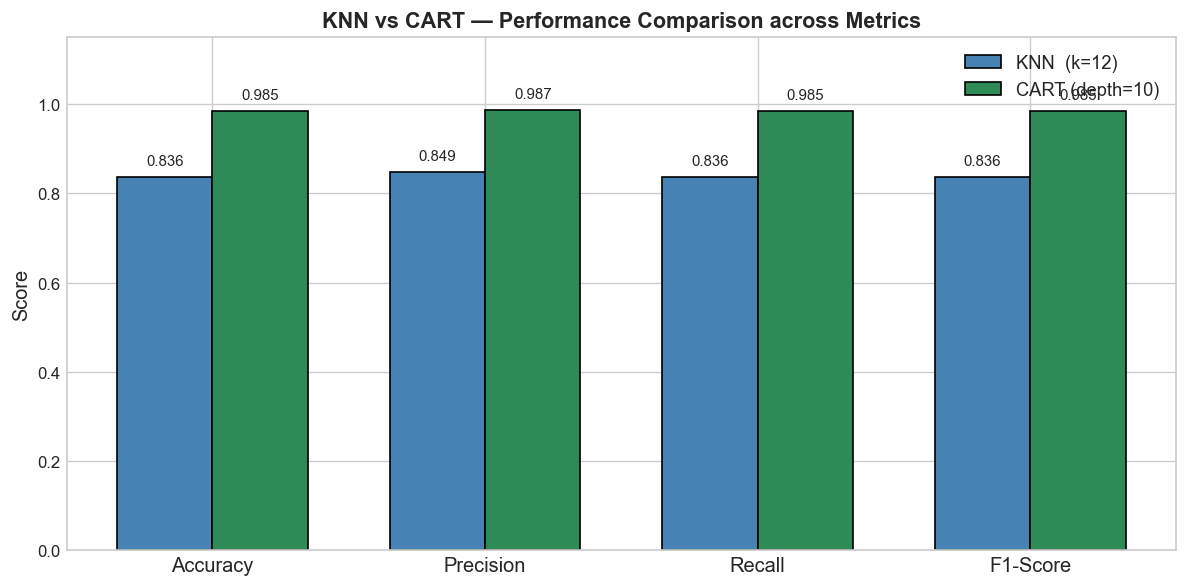


>> Best model by accuracy: CART (depth=10) (0.9851)


In [11]:
# ── Comparison table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'    : [f'KNN  (k={best_k})', f'CART (depth={best_depth})'],
    'Accuracy' : [knn_accuracy,  cart_accuracy],
    'Precision': [knn_precision, cart_precision],
    'Recall'   : [knn_recall,    cart_recall],
    'F1-Score' : [knn_f1,        cart_f1],
})
comparison = comparison.set_index('Model')
print("=" * 60)
print("          MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison.to_string(float_format='{:.4f}'.format))
print("=" * 60)

# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_knn  = ax.bar(x - width/2, comparison.loc[comparison.index[0], metrics],
                   width, label=comparison.index[0], color='steelblue', edgecolor='black')
bars_cart = ax.bar(x + width/2, comparison.loc[comparison.index[1], metrics],
                   width, label=comparison.index[1], color='seagreen', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('KNN vs CART — Performance Comparison across Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

for bar in bars_knn:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_cart:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Winner summary ─────────────────────────────────────────────────────────────
best_model = comparison['Accuracy'].idxmax()
print(f"\n>> Best model by accuracy: {best_model} ({comparison.loc[best_model, 'Accuracy']:.4f})")

## 11. Visualize CART Decision Tree & Feature Importances

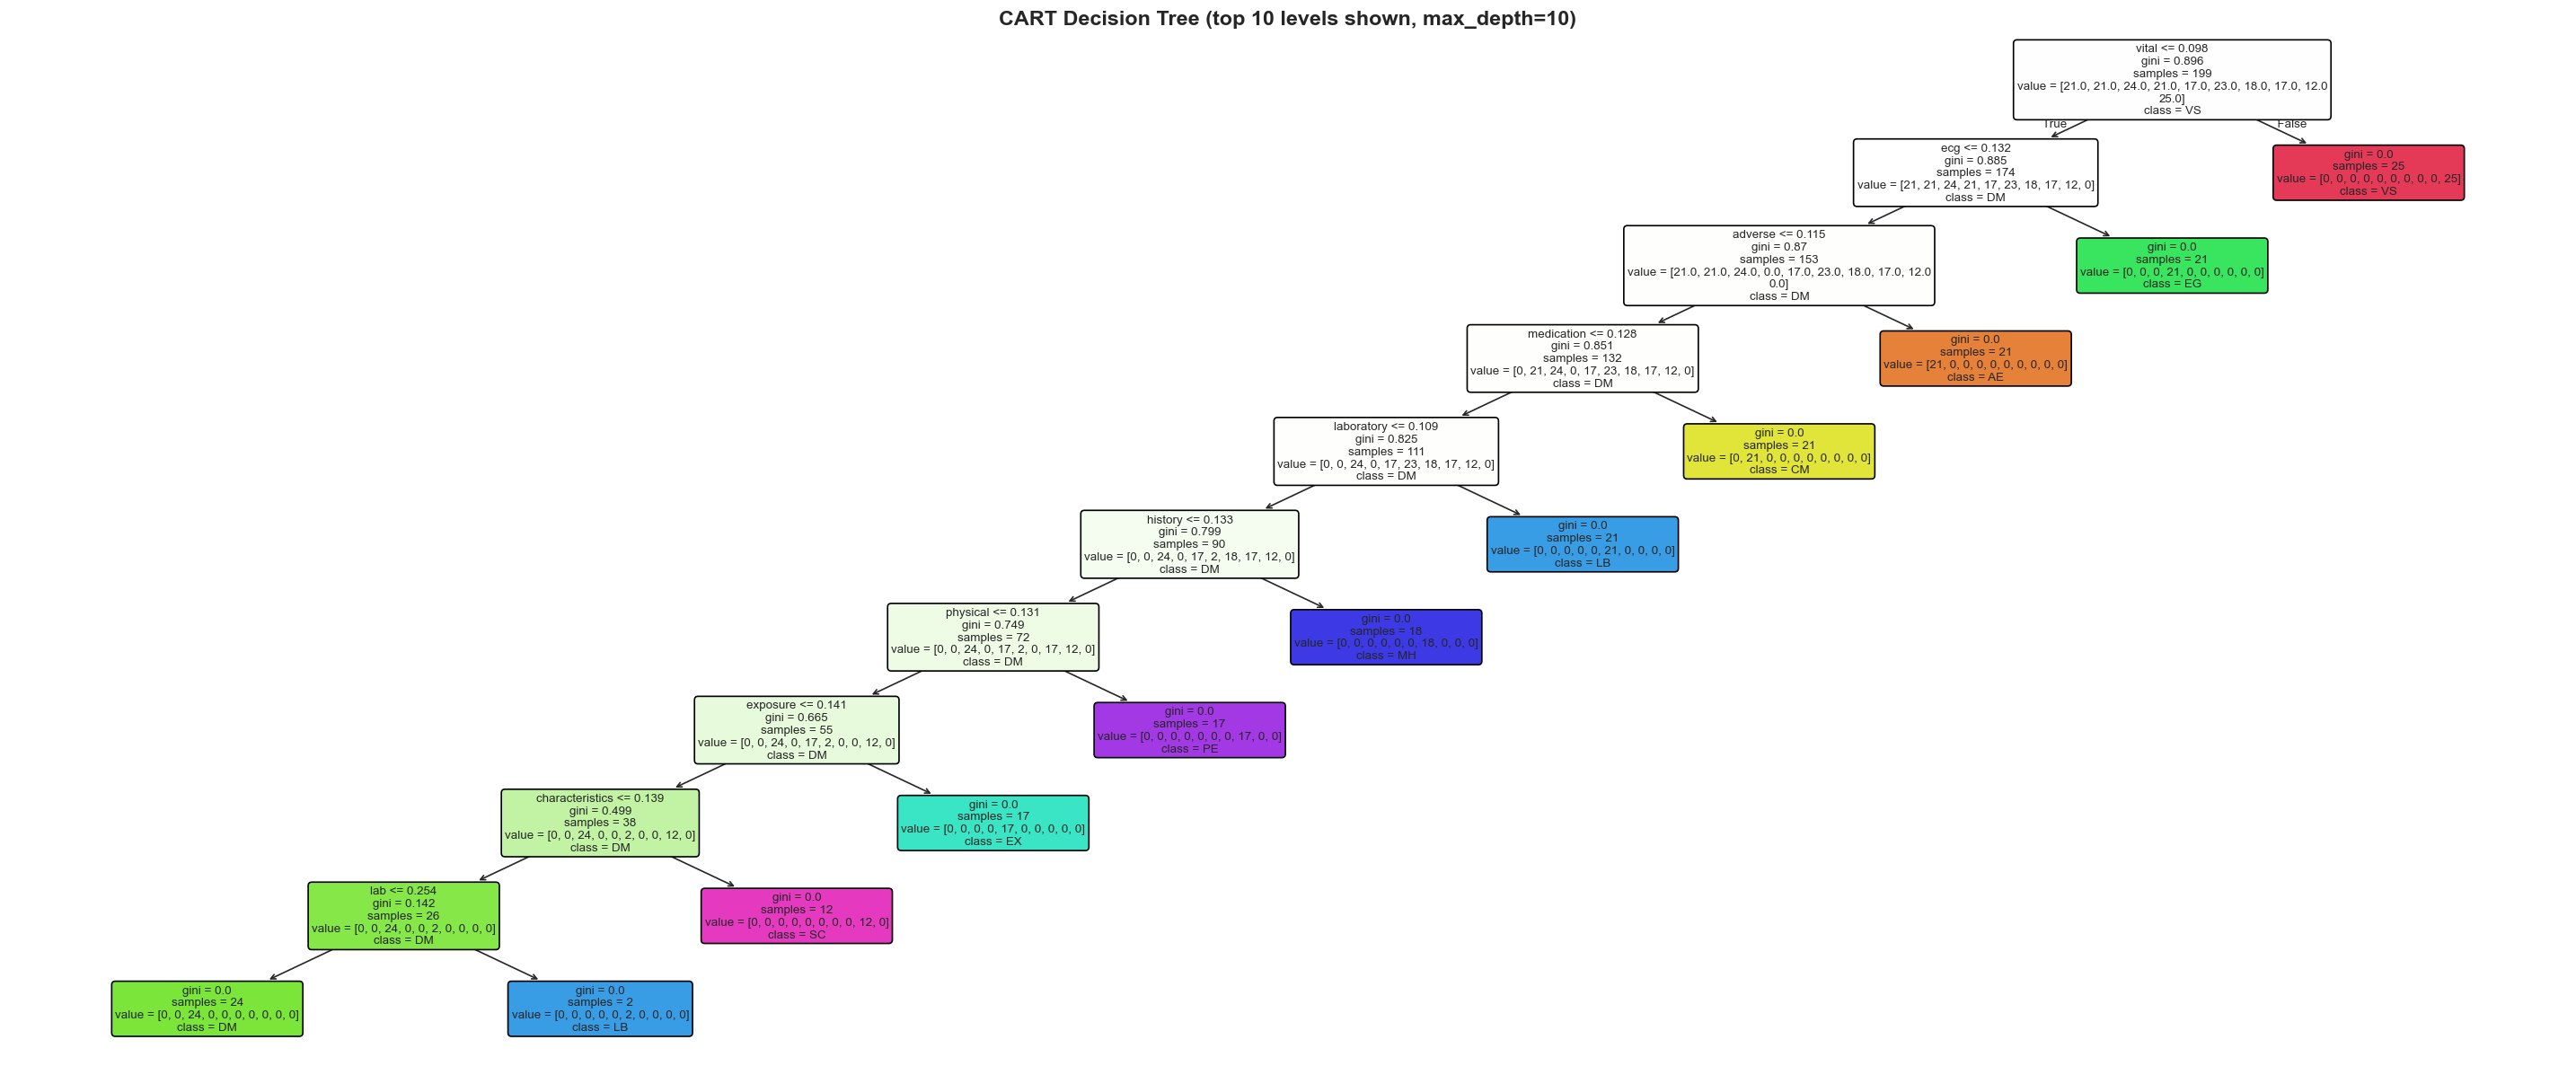

In [14]:
# ── Decision Tree plot (pruned for readability) ───────────────────────────────
tree_viz_depth = 10   # show top 3 levels for clarity

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    cart,
    max_depth=tree_viz_depth,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True
)
ax.set_title(
    f'CART Decision Tree (top {tree_viz_depth} levels shown, max_depth={best_depth})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

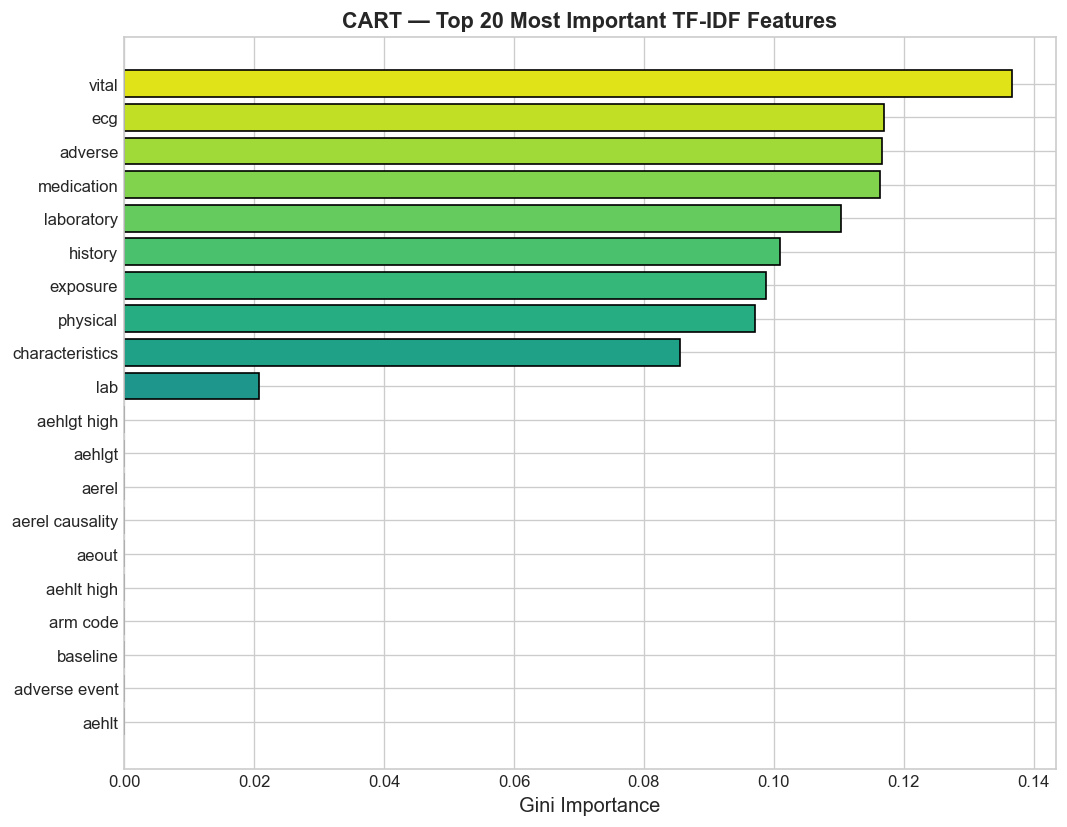


Top 10 most discriminative TF-IDF tokens:
        feature  importance
          vital    0.136588
            ecg    0.116916
        adverse    0.116663
     medication    0.116266
     laboratory    0.110359
        history    0.100989
       exposure    0.098847
       physical    0.097167
characteristics    0.085509
            lab    0.020697


In [13]:
# ── Top-20 Feature Importances ────────────────────────────────────────────────
importances = cart.feature_importances_
feat_importance_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette('viridis', len(feat_importance_df))
ax.barh(feat_importance_df['feature'][::-1],
        feat_importance_df['importance'][::-1],
        color=colors, edgecolor='black')
ax.set_xlabel('Gini Importance', fontsize=12)
ax.set_title('CART — Top 20 Most Important TF-IDF Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 most discriminative TF-IDF tokens:")
print(feat_importance_df[['feature', 'importance']].head(10).to_string(index=False))

---
## Summary

| | KNN | CART |
|---|---|---|
| **Algorithm** | Instance-based (lazy) | Rule-based tree (eager) |
| **Hyper-parameter tuned** | k (neighbors) | max_depth, min_samples_split |
| **Interpretable?** | No | Yes (tree structure) |
| **Feature insight** | No | Yes (Gini importances) |

**Key observations:**
- **KNN** performs well on text features (cosine distance is effective for TF-IDF vectors) but is sensitive to the choice of k.
- **CART** produces an explicit decision tree making it easier to audit which tokens drive which domain predictions — important in a clinical/SDTM context.
- Both models benefit from the combined `variable_name + variable_label` text feature as domain-specific keywords (e.g., *adverse*, *laboratory*, *vital*) are highly discriminative.